#import library

In [ ]:
import os  # For directory and file operations
import numpy as np  # For numerical operations and handling image arrays
import random  # For generating random values for augmentation
from PIL import Image, ImageEnhance  # For image processing and enhancement

from tensorflow.keras.preprocessing.image import load_img  # For loading images
from tensorflow.keras.models import Sequential  # For building the model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense  # For model layers
from tensorflow.keras.optimizers import Adam  # For optimizer

# Import multiple pretrained models
from tensorflow.keras.applications import VGG16, MobileNetV2, ResNet50

# Import corresponding preprocess functions
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

from sklearn.utils import shuffle  # For shuffling the data

#Load dataset

In [ ]:
# ===============================
# Model(Choose model)
# ===============================
model_name = 'vgg16'  # options: 'vgg16', 'mobilenet', 'resnet'

# Set input size based on model
if model_name == 'vgg16' or model_name == 'resnet':
    IMG_SIZE = (224, 224)
elif model_name == 'mobilenet':
    IMG_SIZE = (224, 224)  # MobileNetV2 also uses 224x224
else:
    raise ValueError("Invalid model name")

# ===============================
# Directories
# ===============================
train_dir = '/content/drive/MyDrive/MRI images/Training/'
test_dir = '/content/drive/MyDrive/MRI images/Testing/'

# ===============================
# Load and shuffle training data
# ===============================
train_paths = []
train_labels = []

for label in os.listdir(train_dir):
    label_path = os.path.join(train_dir, label)

    if os.path.isdir(label_path):  # safety check
        for image in os.listdir(label_path):
            train_paths.append(os.path.join(label_path, image))
            train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# ===============================
# Load and shuffle test data
# ===============================
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
    label_path = os.path.join(test_dir, label)

    if os.path.isdir(label_path):  # safety check
        for image in os.listdir(label_path):
            test_paths.append(os.path.join(label_path, image))
            test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

# ===============================
# Class info (VERY IMPORTANT)
# ===============================
classes = sorted(list(set(train_labels)))
num_classes = len(classes)

print("Classes:", classes)
print("Number of classes:", num_classes)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#data visualization

In [1]:
import random
import matplotlib.pyplot as plt

# select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

# loop through random indices and display images
for i, idx in enumerate(random_indices):
    img_path = train_paths[idx]
    img = Image.open(img_path).convert("RGB")  # ensure 3 channels

    # resize according to model
    img = img.resize(IMG_SIZE)

    # display image
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=12)

plt.tight_layout()
plt.show()

NameError: name 'train_paths' is not defined

#image preprocessing

In [ ]:
# ===============================
# Preprocess based on model
# ===============================
def get_preprocess_function(model_name):
    if model_name == 'vgg16':
        return vgg16_preprocess
    elif model_name == 'mobilenet':
        return mobilenet_preprocess
    elif model_name == 'resnet':
        return resnet_preprocess
    else:
        raise ValueError("Invalid model name")

preprocess_fn = get_preprocess_function(model_name)

# ===============================
# Image Augmentation function
# ===============================
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    return np.array(image)

# ===============================
# Load images + preprocess
# ===============================
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=IMG_SIZE)  # use IMG_SIZE
        image = np.array(image)

        # augmentation
        image = augment_image(image)

        # apply model-specific preprocessing
        image = preprocess_fn(image)

        images.append(image)

    return np.array(images)

# ===============================
# Encoding labels
# ===============================
# FIX: use consistent class list
label_to_index = {label: idx for idx, label in enumerate(classes)}

def encode_label(labels):
    return np.array([label_to_index[label] for label in labels])

# ===============================
# Data generator
# ===============================
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)

            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)

            yield batch_images, batch_labels

 # Build Model Function

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D

# ===============================
# Build Model Function
# ===============================
def build_model(model_name, num_classes):

    if model_name == 'vgg16':
        base_model = VGG16(weights='imagenet',
                           include_top=False,
                           input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    elif model_name == 'mobilenet':
        base_model = MobileNetV2(weights='imagenet',
                                 include_top=False,
                                 input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    elif model_name == 'resnet':
        base_model = ResNet50(weights='imagenet',
                              include_top=False,
                              input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    else:
        raise ValueError("Invalid model name")

    # ===============================
    # Freeze layers
    # ===============================
    for layer in base_model.layers:
        layer.trainable = False

    # Unfreeze last few layers (fine-tuning)
    for layer in base_model.layers[-4:]:
        layer.trainable = True

    # ===============================
    # Custom classifier
    # ===============================
    model = Sequential([
        Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        base_model,
        GlobalAveragePooling2D(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])

    # ===============================
    # Compile
    # ===============================
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['sparse_categorical_accuracy']
    )

    return model


# ===============================
# Build model
# ===============================
model = build_model(model_name, num_classes)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 7,145,604 (27.26 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

#training part

In [ ]:
# Parameters
batch_size = 64
steps = int(len(train_paths) / batch_size)
epochs = 5

# Train
history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    epochs=epochs,
    steps_per_epoch=steps
)

Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 1482s 17s/step - loss: 0.7425 - sparse_categorical_accuracy: 0.7404
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 64s 674ms/step - loss: 0.3358 - sparse_categorical_accuracy: 0.8770
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 61s 691ms/step - loss: 0.2238 - sparse_categorical_accuracy: 0.9242
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 60s 682ms/step - loss: 0.1426 - sparse_categorical_accuracy: 0.9483
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 60s 681ms/step - loss: 0.1127 - sparse_categorical_accuracy: 0.9645


#save model

In [ ]:
model.save('/content/drive/MyDrive/my_trained_model.h5')

In [ ]:
#for reloud
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/my_trained_model.h5')

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/my_trained_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

# detect_and_display

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img
import numpy as np

def detect_and_display(image_path, model):
    # 1️⃣ Load image
    img = load_img(image_path, target_size=IMG_SIZE)  # same as training size
    img_array = np.array(img)

    # 2️⃣ Preprocess for your model
    img_array = preprocess_fn(img_array)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # 3️⃣ Predict
    pred = model.predict(img_array)
    pred_class = classes[np.argmax(pred)]
    confidence = np.max(pred)

    # 4️⃣ Display
    plt.imshow(load_img(image_path))
    plt.axis('off')
    plt.title(f"Predicted: {pred_class} ({confidence*100:.2f}%)")
    plt.show()

    return pred_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


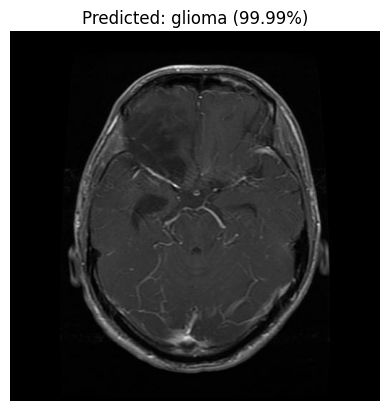

Predicted class: glioma, Confidence: 1.00


In [ ]:
image_path = '/content/drive/MyDrive/MRI images/Testing/glioma/Te-gl_100.jpg'
pred_class, confidence = detect_and_display(image_path, model)
print(f"Predicted class: {pred_class}, Confidence: {confidence:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


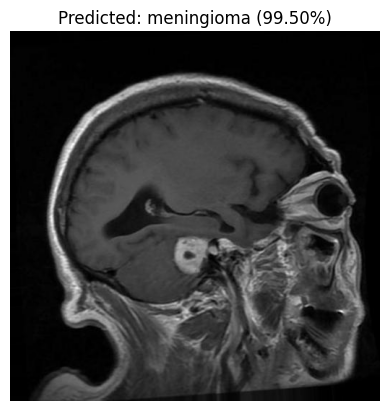

Predicted class: meningioma, Confidence: 1.00


In [ ]:
image_path = '/content/drive/MyDrive/MRI images/Testing/meningioma/Te-aug-me_100.jpg'
pred_class, confidence = detect_and_display(image_path, model)
print(f"Predicted class: {pred_class}, Confidence: {confidence:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


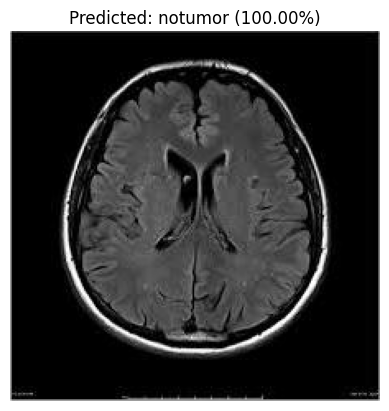

Predicted class: notumor, Confidence: 1.00


In [ ]:
image_path = '/content/drive/MyDrive/MRI images/Testing/notumor/Te-no_104.jpg'
pred_class, confidence = detect_and_display(image_path, model)
print(f"Predicted class: {pred_class}, Confidence: {confidence:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


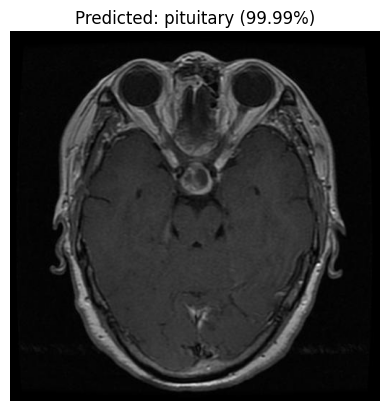

Predicted class: pituitary, Confidence: 1.00


In [ ]:
image_path = '/content/drive/MyDrive/MRI images/Testing/pituitary/Te-pi_108.jpg'
pred_class, confidence = detect_and_display(image_path, model)
print(f"Predicted class: {pred_class}, Confidence: {confidence:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


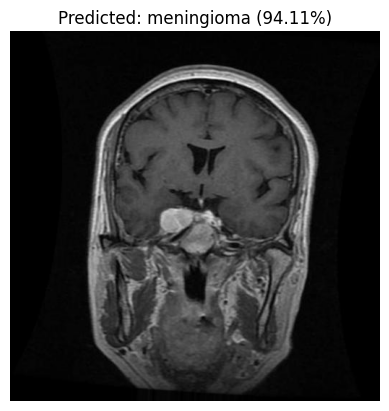

Predicted class: meningioma, Confidence: 0.94


In [ ]:
image_path = '/content/drive/MyDrive/MRI images/Testing/meningioma/Te-aug-me_12.jpg'
pred_class, confidence = detect_and_display(image_path, model)
print(f"Predicted class: {pred_class}, Confidence: {confidence:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


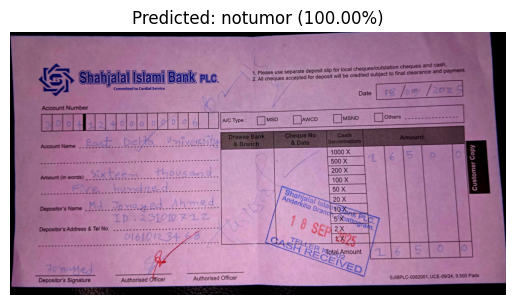

Predicted class: notumor, Confidence: 1.00


In [ ]:
image_path = '/content/drive/MyDrive/IMG_20250918_124639.jpg'
pred_class, confidence = detect_and_display(image_path, model)
print(f"Predicted class: {pred_class}, Confidence: {confidence:.2f}")